# 个人收入整合系统
**参考管理会计利润表结构 · 按流动性分层（低 → 高）**

| 层级 | 资产类型 | 流动性 |
|------|----------|--------|
| 社会保障层 | 养老保险 | ★☆☆☆☆ |
| 社会保障层 | 住房公积金 | ★★☆☆☆ |
| 保险保障层 | 商业保险（储蓄险） | ★★☆☆☆ |
| 投资层 | 基金 | ★★★☆☆ |
| 投资层 | A 股 | ★★★★☆ |
| 现金等价物层 | 银行存款 | ★★★★★ |

**核心指标**：综合收益率 · 现金净现值（NPV）· 等值年金 · 基期对比（两个节点）

In [1]:
# 首次运行请先执行本格安装依赖
import subprocess, sys
for pkg in ['akshare', 'numpy-financial', 'python-dateutil']:
    try:
        __import__(pkg.replace('-', '_').split('_')[0] if pkg != 'python-dateutil' else 'dateutil')
    except ImportError:
        print(f'正在安装 {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import pandas as pd
import numpy as np
import numpy_financial as npf
from datetime import date
from dateutil.relativedelta import relativedelta
import warnings
warnings.filterwarnings('ignore')

try:
    import akshare as ak
    AK = True
    print('✓ akshare 已加载，A 股实时行情可用')
except ImportError:
    AK = False
    print('⚠ akshare 未加载，A 股须手动填入价格')

pd.options.display.float_format = '{:,.2f}'.format
TODAY = date.today()
print(f'今日：{TODAY}')

✓ akshare 已加载，A 股实时行情可用
今日：2026-06-17


---
## 第一步：全局参数
**只需修改本格，后续所有计算自动更新。**

In [2]:
# ===== 📋 全局参数（在此修改）=====

DISCOUNT_RATE   = 0.03            # 折现率（国债基准利率，一般取 3%）

# 两个历史参考节点（用于资产积累趋势对比）
DATE_BASE_1     = date(2020, 1, 1)   # 基期起始——开始认真积累资产的时间
DATE_BASE_2     = date(2023, 1, 1)   # 中间参考节点

# 退休规划
DATE_RETIRE     = date(2040, 1, 1)   # 预计退休日期
DATE_LIFE_END   = date(2080, 1, 1)   # 预期寿命终止日（终身年金折现到此）

# ====================

years_to_retire  = relativedelta(DATE_RETIRE, TODAY)
years_life_total = relativedelta(DATE_LIFE_END, TODAY)
HORIZON_YEARS    = (DATE_LIFE_END - TODAY).days / 365.25

# 2036 退休推算用的投资层预期年化收益率（与当前持仓历史年化解耦，手动设定）
PROJ_INVEST_RATE = 0.05   # ← 可修改，建议参考：保守 3-4%，中性 5-6%，激进 7-8%

print(f'折现率：{DISCOUNT_RATE:.1%}')
print(f'基期起始：{DATE_BASE_1}  |  基期对比节点：{DATE_BASE_2}')
print(f'距退休：{years_to_retire.years} 年 {years_to_retire.months} 个月')
print(f'规划总年限（至预期寿命）：{HORIZON_YEARS:.0f} 年')


折现率：3.0%
基期起始：2020-01-01  |  基期对比节点：2023-01-01
距退休：13 年 6 个月
规划总年限（至预期寿命）：54 年


---
## 工具函数（无需修改）

In [3]:
def pv_annuity(pmt, rate_annual, n_months, delay_months=0):
    """等额月金的现值，delay_months：距第一次领取还有多少月"""
    r = (1 + rate_annual) ** (1/12) - 1
    if r == 0:
        pv_at_start = pmt * n_months
    else:
        pv_at_start = pmt * (1 - (1+r)**(-n_months)) / r
    return pv_at_start / (1+r)**delay_months


def pv_lump(fv, rate_annual, years):
    """一次性未来收入的现值"""
    return fv / (1 + rate_annual)**years


def eaa(total_npv, rate_annual, years):
    """净现值 → 等值年金（EAA）"""
    if years <= 0:
        return 0
    if rate_annual == 0:
        return total_npv / years
    pvifa = (1 - (1 + rate_annual)**(-years)) / rate_annual
    return total_npv / pvifa


def annualized_return(end_val, start_val, years):
    """年化收益率，持有期 < 0.01 年时返回 0"""
    if start_val <= 0 or years < 0.01:
        return 0.0
    return (end_val / start_val) ** (1/years) - 1


def cagr(start_val, end_val, years):
    return annualized_return(end_val, start_val, years)


print('工具函数加载完成')

工具函数加载完成


---
## 第二步：A 股查询工具
输入股票代码或名称关键字，确认后填入第五步的持仓表。

In [4]:
import os
import requests as _req

# 固定绕过所有代理的 Session（系统代理 + 环境变量都不走）
_session = _req.Session()
_session.trust_env = False   # 不读 HTTP_PROXY 等环境变量
_PROXIES = {'http': None, 'https': None}  # 显式禁用代理


def _sina_quote(codes: list) -> dict:
    """新浪行情接口——批量查 A 股/ETF 实时价格"""
    prefixed = [('sh' if c.startswith(('6', '5')) else 'sz') + c for c in codes]
    url = 'https://hq.sinajs.cn/list=' + ','.join(prefixed)
    headers = {
        'Referer':    'https://finance.sina.com.cn',
        'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) '
                      'AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36',
    }
    r = _session.get(url, headers=headers, timeout=10, proxies=_PROXIES)
    r.encoding = 'gbk'

    result = {}
    for line in r.text.strip().splitlines():
        if '="' not in line:
            continue
        code  = line.split('"')[0].rstrip('=')[-6:]
        inner = line.split('"')[1]
        if not inner:
            continue
        parts = inner.split(',')
        if len(parts) < 7:
            continue
        name    = parts[0]
        yclose  = float(parts[1]) if parts[1] else 0
        price   = float(parts[3]) if parts[3] else 0
        if price == 0:  # 涨停封死时最新价为 0，用买一价补位
            price = float(parts[6]) if parts[6] else 0
        chg_pct = round((price - yclose) / yclose * 100, 2) if yclose else 0
        result[code] = {'name': name, 'price': price, 'change_pct': chg_pct}
    return result


def search_stock(query: str):
    """按代码或名称搜索 A 股，返回 DataFrame"""
    if not AK:
        print('akshare 不可用，请手动填写代码和名称')
        return
    try:
        import akshare as _ak
        df = _ak.stock_info_a_code_name()
        mask = (df['code'].str.contains(query, na=False) |
                df['name'].str.contains(query, na=False))
        result = df[mask].reset_index(drop=True)
        print(f'搜索 "{query}"，共 {len(result)} 条结果：')
        return result
    except Exception as e:
        print(f'查询失败：{e}')


_quote_cache: dict = {}

def get_price(code: str) -> dict:
    """获取单只 A 股实时行情（新浪接口，直连）"""
    global _quote_cache
    if code not in _quote_cache:
        try:
            _quote_cache.update(_sina_quote([code]))
        except Exception as e:
            print(f'{code} 行情获取失败：{e}')
            return {}
    return _quote_cache.get(code, {})


def get_fund_price(code: str) -> dict:
    """
    获取基金最新价格/净值（直连，绕过代理）。
    优先走天天基金API（开放式基金+ETF联接），拿不到再走新浪（纯ETF场内）。
    避免基金代码与同名A股代码冲突（如 sz001286=陕西能源 vs 001286=易方达新鑫混合E）。
    """
    import re as _re, json as _json

    # -- 优先：天天基金估值接口（开放式基金 / ETF联接） --
    try:
        url = f'https://fundgz.1234567.com.cn/js/{code}.js'
        r = _session.get(url,
                         headers={'Referer': 'https://fund.eastmoney.com/'},
                         timeout=10,
                         proxies=_PROXIES)
        m = _re.search(r'\((.+)\)', r.text)
        if m:
            d = _json.loads(m.group(1))
            price = float(d.get('gsz') or d.get('dwjz', 0))
            chg   = float(d.get('gszzl', 0))
            label = '盘中估值' if d.get('gsz') else 'T-1净值'
            return {
                'name':       d.get('name', code),
                'price':      price,
                'change_pct': chg,
                'type':       f'开放式基金({label})',
            }
    except Exception:
        pass

    # -- 备选：新浪实时（场内ETF，天天基金无数据） --
    try:
        info = _sina_quote([code]).get(code, {})
        if info and info.get('price', 0) > 0:
            info['type'] = 'ETF'
            return info
    except Exception as e:
        print(f'{code} 基金行情获取失败：{e}')

    return {}

print('行情工具函数加载完成（直连，已绕过代理）')


行情工具函数加载完成（直连，已绕过代理）


In [5]:
# ===== 修改查询词 =====
# search_stock('盛和资源')  # akshare 依赖，按需手动在 Jupyter 中运行

---
## 第三步：逐层录入资产

> **提示**：每层只需修改带 `# ← 改这里` 注释的字段，其余计算自动完成。

### 层 1 · 养老保险（最低流动性）

In [6]:
# ===== 📋 养老保险参数（在此修改）=====
# 数据来源：社保局 App「个人养老金账户」
PENSION_PARAMS = {
    # 个人账户
    'personal_account':      100_000,   # ← 个人账户余额（元）
    'cost_basis':            100_000,   # ← 历史累计个人缴纳总额

    # 退休预测
    'monthly_pension':         3_000,   # ← 预计退休后月领金额（可用社保局测算工具估算）
    'account_annual_return':   0.055,   # ← 个人账户记账利率（官方约 5.5%，每年调整）
}
# ====================

delay_m  = (DATE_RETIRE - TODAY).days // 30
receive_m = (DATE_LIFE_END - DATE_RETIRE).days // 30
PENSION = PENSION_PARAMS.copy()

PENSION['npv'] = pv_annuity(
    PENSION['monthly_pension'],
    DISCOUNT_RATE,
    receive_m,
    delay_months=delay_m
)
PENSION['annualized_return'] = PENSION['account_annual_return']

print(f"养老保险")
print(f"  个人账户余额       ：¥{PENSION['personal_account']:>12,.0f}")
print(f"  成本基础           ：¥{PENSION['cost_basis']:>12,.0f}")
print(f"  距退休             ：{delay_m} 个月")
print(f"  预计领取           ：{receive_m} 个月（{receive_m//12} 年，终身）")
print(f"  月领金额           ：¥{PENSION['monthly_pension']:>12,.0f}")
print(f"  终身年金 NPV       ：¥{PENSION['npv']:>12,.0f}")


养老保险
  个人账户余额       ：¥     100,000
  成本基础           ：¥     100,000
  距退休             ：164 个月
  预计领取           ：487 个月（40 年，终身）
  月领金额           ：¥       3,000
  终身年金 NPV       ：¥     567,439


### 层 2 · 住房公积金

In [7]:
# ===== 📋 住房公积金参数（在此修改）=====
# 数据来源：公积金 App 或官网账户查询
HPF = {
    'balance':              80_000,   # ← 当前余额（个人缴纳部分）
    'cost_basis':           80_000,   # ← 历史累计个人缴纳
    'annual_rate':           0.025,   # ← 年化利率（现行基准 2.5%）
    'expected_use_years':     10.0,   # ← 预计几年后动用（买房/退休提取）
    'note': '预计用于首付',             # ← 备注
}
# ====================

HPF['future_value']     = HPF['balance'] * (1 + HPF['annual_rate']) ** HPF['expected_use_years']
HPF['npv']              = pv_lump(HPF['future_value'], DISCOUNT_RATE, HPF['expected_use_years'])
HPF['annualized_return'] = HPF['annual_rate']

print(f"住房公积金")
print(f"  当前余额           ：¥{HPF['balance']:>12,.0f}")
print(f"  {HPF['expected_use_years']:.0f} 年后取出预估     ：¥{HPF['future_value']:>12,.0f}")
print(f"  NPV                ：¥{HPF['npv']:>12,.0f}")
print(f"  备注：{HPF['note']}")


住房公积金
  当前余额           ：¥      80,000
  10 年后取出预估     ：¥     102,407
  NPV                ：¥      76,200
  备注：预计用于首付


### 层 3 · 商业保险（储蓄险）

In [8]:
# ===== 📋 储蓄险参数（在此修改，可添加多张保单）=====
# 数据来源：保单合同 / 保险公司 App
INSURANCE_LIST = [
    {
        'name':               'XX 年金保险',      # ← 保单名称
        'cash_value':              50_000,        # ← 当前现金价值（退保可得，见保单）
        'cost_basis':              50_000,        # ← 已缴保费合计
        'annual_premium':               0,        # ← 年缴保费（已缴完填 0）
        'premium_years_left':           0,        # ← 还需缴纳年数
        'maturity_value':          50_000,        # ← 满期/减保可领金额
        'years_to_maturity':            0,        # ← 距满期年数（已到期填 0）
        'policy_irr':               0.030,        # ← 保单 IRR（投保书/说明书上有）
    },
    {
        'name':               'XX 终身寿险',
        'cash_value':              30_000,
        'cost_basis':              30_000,
        'annual_premium':          10_000,        # ← 每年还需缴纳
        'premium_years_left':           5,        # ← 还需缴 5 年
        'maturity_value':          80_000,
        'years_to_maturity':            5,
        'policy_irr':               0.028,
    },
    # 继续添加保单，复制上方字典块即可
]
# ====================

for ins in INSURANCE_LIST:
    pv_mat = pv_lump(ins['maturity_value'], DISCOUNT_RATE, ins['years_to_maturity'])
    pv_prem = 0.0
    if ins['premium_years_left'] > 0 and DISCOUNT_RATE > 0:
        pvifa = (1 - (1+DISCOUNT_RATE)**(-ins['premium_years_left'])) / DISCOUNT_RATE
        pv_prem = ins['annual_premium'] * pvifa
    ins['pv_maturity']   = pv_mat
    ins['pv_premiums']   = pv_prem
    ins['npv']           = ins['cash_value'] + pv_mat - pv_prem
    ins['annualized_return'] = ins['policy_irr']

    print(f"储蓄险：{ins['name']}")
    print(f"  当前现金价值       ：¥{ins['cash_value']:>12,.0f}")
    print(f"  满期价值现值       ：¥{ins['pv_maturity']:>12,.0f}")
    print(f"  未来保费现值（支出）：¥{ins['pv_premiums']:>12,.0f}")
    print(f"  保单综合 NPV       ：¥{ins['npv']:>12,.0f}")
    print(f"  保单 IRR           ：{ins['policy_irr']:.2%}")
    print()


储蓄险：XX 年金保险
  当前现金价值       ：¥      50,000
  满期价值现值       ：¥      50,000
  未来保费现值（支出）：¥           0
  保单综合 NPV       ：¥     100,000
  保单 IRR           ：3.00%

储蓄险：XX 终身寿险
  当前现金价值       ：¥      30,000
  满期价值现值       ：¥      69,009
  未来保费现值（支出）：¥      45,797
  保单综合 NPV       ：¥      53,212
  保单 IRR           ：2.80%



In [9]:
# ===== 📋 基金持仓（在此修改）=====
# cost_nav  → 券商 App「持仓成本」（移动加权均价，含历史卖出影响）
# shares    → 持有份额（元/份）
# buy_date  → 首次建仓日（近似值，用于年化收益率估算）
# manual_nav → 手动覆盖净值（None = 自动从接口获取）
FUND_INPUT = [
    {'code': '000001', 'shares': 10000.00, 'cost_nav': 1.5000, 'buy_date': date(2023, 1, 1), 'manual_nav': None},
    {'code': '110022', 'shares':  5000.00, 'cost_nav': 2.1000, 'buy_date': date(2023, 6, 1), 'manual_nav': None},
    {'code': '270023', 'shares':  3000.00, 'cost_nav': 4.5000, 'buy_date': date(2024, 1, 1), 'manual_nav': None},
    # 继续添加：{'code': '510300', 'shares': 5000, 'cost_nav': 4.20, 'buy_date': date(2023,1,1), 'manual_nav': None},
]
# ====================

FUND_LIST = []
for f in FUND_INPUT:
    info     = get_fund_price(f['code'])
    nav      = info.get('price') or f['manual_nav'] or f['cost_nav']
    name     = info.get('name') or f['code']
    ftype    = info.get('type', '手动录入')
    chg      = info.get('change_pct', None)
    hold_yrs = (TODAY - f['buy_date']).days / 365.25
    mv       = nav * f['shares']
    cost     = f['cost_nav'] * f['shares']

    FUND_LIST.append({
        'code':              f['code'],
        'name':              name,
        'type':              ftype,
        'shares':            f['shares'],
        'nav':               nav,
        'change_pct_today':  chg,
        'market_value':      mv,
        'cost_basis':        cost,
        'total_return':      mv - cost,
        'return_pct':       (mv - cost) / cost if cost else 0,
        'annualized_return': annualized_return(mv, cost, hold_yrs),
        'holding_years':     hold_yrs,
        'npv':               mv,
        'cost_nav':          f['cost_nav'],
        'buy_date':          f['buy_date'],
    })

df_funds = pd.DataFrame(FUND_LIST)[[
    'code','name','type','shares','nav','change_pct_today',
    'market_value','cost_basis','total_return','return_pct','annualized_return'
]]
df_funds.columns = ['代码','名称','类型','份额','净值/现价','今日涨跌%','市值','成本','浮盈','总收益率','年化收益率']
print(df_funds.to_string(index=False))
print(f"\n基金合计市值：¥{sum(f['market_value'] for f in FUND_LIST):,.0f}")


    代码                 名称          类型        份额  净值/现价  今日涨跌%        市值        成本        浮盈  总收益率  年化收益率
000001             华夏成长混合 开放式基金(盘中估值) 10,000.00   1.38   1.42 13,773.00 15,000.00 -1,227.00 -0.08  -0.02
110022          易方达消费行业股票 开放式基金(盘中估值)  5,000.00   2.71  -1.19 13,537.50 10,500.00  3,037.50  0.29   0.09
270023 广发全球精选股票(QDII)人民币A 开放式基金(盘中估值)  3,000.00   7.09   0.36 21,280.20 13,500.00  7,780.20  0.58   0.20

基金合计市值：¥48,591


### 层 4 · 基金

### 层 5 · A 股

In [10]:
# ===== 📋 A股/ETF 持仓（在此修改）=====
# cost_price → 券商 App「持仓成本」
# buy_date   → 首次建仓日（近似值，用于年化收益率估算）
# manual_price → 手动覆盖价格（None = 自动从新浪行情获取）
STOCK_INPUT = [
    {'code': '600036', 'shares': 100, 'cost_price': 35.00, 'buy_date': date(2023, 1, 1), 'manual_price': None},
    {'code': '000001', 'shares': 200, 'cost_price': 12.50, 'buy_date': date(2023, 6, 1), 'manual_price': None},
    # 场内 ETF 同样填这里：{'code': '510300', 'shares': 1000, ...}
    # 继续添加...
]
# ====================

STOCK_HOLDINGS = []
for s in STOCK_INPUT:
    info     = get_price(s['code'])
    price    = info.get('price') or s['manual_price'] or s['cost_price']
    name     = info.get('name') or s['code']
    chg      = info.get('change_pct', None)
    hold_yrs = (TODAY - s['buy_date']).days / 365.25
    mv       = price * s['shares']
    cost     = s['cost_price'] * s['shares']

    STOCK_HOLDINGS.append({
        'code':              s['code'],
        'name':              name,
        'shares':            s['shares'],
        'current_price':     price,
        'change_pct_today':  chg,
        'market_value':      mv,
        'cost_basis':        cost,
        'total_return':      mv - cost,
        'return_pct':       (mv - cost) / cost if cost else 0,
        'annualized_return': annualized_return(mv, cost, hold_yrs),
        'holding_years':     hold_yrs,
        'npv':               mv,
    })

df_stocks = pd.DataFrame(STOCK_HOLDINGS)[[
    'code','name','shares','current_price','change_pct_today',
    'market_value','cost_basis','total_return','return_pct','annualized_return'
]]
df_stocks.columns = ['代码','名称','股数','现价','今日涨跌%','市值','成本','浮盈','总收益率','年化收益率']
print(df_stocks.to_string(index=False))
print(f"\nA 股合计市值：¥{sum(s['market_value'] for s in STOCK_HOLDINGS):,.0f}")


    代码   名称  股数    现价  今日涨跌%       市值       成本      浮盈  总收益率  年化收益率
600036 招商银行 100 38.24  -1.14 3,824.00 3,500.00  324.00  0.09   0.03
000001 平安银行 200 10.83  -1.28 2,166.00 2,500.00 -334.00 -0.13  -0.05

A 股合计市值：¥5,990


### 层 6 · 银行存款（最高流动性）

In [11]:
# ===== 📋 银行存款（在此修改）=====
DEPOSIT_LIST = [
    {'type': '活期', 'bank': '工商银行',   'balance': 50_000, 'rate': 0.002, 'term_years': 0},
    {'type': '活期', 'bank': '支付宝余额宝', 'balance': 20_000, 'rate': 0.018, 'term_years': 0},
    {'type': '定期', 'bank': '招商银行',   'balance': 50_000, 'rate': 0.020, 'term_years': 1},
    # 继续添加：{'type': '活期', 'bank': 'XX 银行', 'balance': 10000, 'rate': 0.002, 'term_years': 0},
]
# ====================

for d in DEPOSIT_LIST:
    t = d['term_years']
    d['future_value']      = d['balance'] * (1 + d['rate']) ** max(t, 1)
    d['npv']               = pv_lump(d['future_value'], DISCOUNT_RATE, max(t, 0.001))
    d['annualized_return']  = d['rate']
    d['cost_basis']         = d['balance']
    print(f"存款 {d['bank']}（{d['type']}）：¥{d['balance']:>12,.0f}  利率 {d['rate']:.1%}")

print(f"\n存款合计：¥{sum(d['balance'] for d in DEPOSIT_LIST):,.0f}")


存款 工商银行（活期）：¥      50,000  利率 0.2%
存款 支付宝余额宝（活期）：¥      20,000  利率 1.8%
存款 招商银行（定期）：¥      50,000  利率 2.0%

存款合计：¥120,000


In [12]:
# ===== 修改这里：历史已实现盈亏（从券商年度账单 / 交割单读取）=====
# 仅用于综合报表参考展示，不影响 NPV / 退休推算
REALIZED_GAINS = {
    '基金':  0,   # ← 历年卖出基金累计已实现盈亏（元）
    'A股':   0,   # ← 历年卖出A股累计已实现盈亏（元）
}
TOTAL_REALIZED = sum(REALIZED_GAINS.values())
print(f'历史已实现盈亏合计：¥{TOTAL_REALIZED:+,.0f}')
for k, v in REALIZED_GAINS.items():
    if v != 0:
        print(f'  {k}：¥{v:+,.0f}')

历史已实现盈亏合计：¥+0


---
## 第四步：个人资产收益整合表
**管理会计利润表结构 · 按流动性分层**

In [13]:
# 汇总所有资产到一张表
rows = []

# -- 养老保险 --
rows.append({
    'layer': '① 社会保障层', 'category': '养老保险',
    'market_value': PENSION['personal_account'],
    'cost_basis':   PENSION['cost_basis'],
    'npv':          PENSION['npv'],
    'annual_return': PENSION['annualized_return'],
    'cash_flow':    '终身月领年金',
    'monthly_annuity': PENSION['monthly_pension'],
})

# -- 公积金 --
rows.append({
    'layer': '① 社会保障层', 'category': '住房公积金',
    'market_value': HPF['balance'],
    'cost_basis':   HPF['cost_basis'],
    'npv':          HPF['npv'],
    'annual_return': HPF['annualized_return'],
    'cash_flow':    f"{HPF['expected_use_years']:.0f}年后一次性",
    'monthly_annuity': 0,
})

# -- 储蓄险 --
for ins in INSURANCE_LIST:
    rows.append({
        'layer': '② 保险保障层', 'category': f"储蓄险·{ins['name']}",
        'market_value': ins['cash_value'],
        'cost_basis':   ins['cost_basis'],
        'npv':          ins['npv'],
        'annual_return': ins['annualized_return'],
        'cash_flow':    '满期领取',
        'monthly_annuity': 0,
    })

# -- 基金 --
for f in FUND_LIST:
    rows.append({
        'layer': '③ 投资层', 'category': f"基金·{f['name']}",
        'market_value': f['market_value'],
        'cost_basis':   f['cost_basis'],
        'npv':          f['npv'],
        'annual_return': f['annualized_return'],
        'cash_flow':    '随时赎回',
        'monthly_annuity': 0,
    })

# -- A 股 --
for s in STOCK_HOLDINGS:
    rows.append({
        'layer': '③ 投资层', 'category': f"A股·{s['name']}({s['code']})",
        'market_value': s['market_value'],
        'cost_basis':   s['cost_basis'],
        'npv':          s['npv'],
        'annual_return': s['annualized_return'],
        'cash_flow':    'T+1 变现',
        'monthly_annuity': 0,
    })

# -- 银行存款 --
for d in DEPOSIT_LIST:
    rows.append({
        'layer': '④ 现金等价物层', 'category': f"存款·{d['bank']}·{d['type']}",
        'market_value': d['balance'],
        'cost_basis':   d['cost_basis'],
        'npv':          d['npv'],
        'annual_return': d['annualized_return'],
        'cash_flow':    '活期/到期',
        'monthly_annuity': 0,
    })

df = pd.DataFrame(rows)
df['unrealized_gain'] = df['market_value'] - df['cost_basis']
df['return_pct']      = df['unrealized_gain'] / df['cost_basis']

# 加权平均收益率（以成本为权重）
total_cost_all  = df['cost_basis'].sum()
df['weight']    = df['cost_basis'] / total_cost_all
weighted_return = (df['weight'] * df['annual_return']).sum()

# 整合 NPV & 等值年金
total_npv = df['npv'].sum()
EAA_annual  = eaa(total_npv, DISCOUNT_RATE, HORIZON_YEARS)

# ===== 打印整合表 =====
SEP = '─' * 88
DSEP = '═' * 88

print(DSEP)
print(f"{'个人资产收益整合表':^50}")
print(f"{'（管理会计利润表结构 · 按流动性排列）':^50}")
print(f"  基准日期：{TODAY}    折现率：{DISCOUNT_RATE:.1%}    规划年限：{HORIZON_YEARS:.0f}年")
print(DSEP)
print(f"  {'资产':<28} {'市值/余额':>11} {'成本基础':>11} {'浮盈':>10} {'年化收益率':>10} {'NPV':>12}")

layer_totals = {}
for layer_name in df['layer'].unique():
    sub = df[df['layer'] == layer_name]
    print(SEP)
    print(f"  {layer_name}")
    for _, r in sub.iterrows():
        cat = r['category'][:26]
        gain_str = f"{r['unrealized_gain']:+,.0f}"
        print(f"    {cat:<26} {r['market_value']:>11,.0f} {r['cost_basis']:>11,.0f} "
              f"{gain_str:>10} {r['annual_return']:>9.1%}  {r['npv']:>12,.0f}")
    # 小计
    smv  = sub['market_value'].sum()
    scst = sub['cost_basis'].sum()
    snpv = sub['npv'].sum()
    sgain = smv - scst
    print(f"  {'  小计':<28} {smv:>11,.0f} {scst:>11,.0f} {sgain:>+10,.0f} {'':>10}  {snpv:>12,.0f}")
    layer_totals[layer_name] = {'mv': smv, 'cost': scst, 'npv': snpv}

print(DSEP)
total_mv    = df['market_value'].sum()
total_gain  = total_mv - total_cost_all
print(f"  {'【合计】':<28} {total_mv:>11,.0f} {total_cost_all:>11,.0f} {total_gain:>+10,.0f}")
if TOTAL_REALIZED != 0:
    print(f"  {'  历史已实现盈亏':<28} {'':>11} {'':>11} {TOTAL_REALIZED:>+10,.0f}")
    print(f"  {'  综合总盈亏（含已实现）':<28} {'':>11} {'':>11} {total_gain+TOTAL_REALIZED:>+10,.0f}")
print()
print(f"  加权平均年化收益率   ：{weighted_return:>8.2%}")
print(f"  现金净现值（NPV）    ：¥{total_npv:>14,.0f}")
print(f"  等值年金（至预期寿命）：¥{EAA_annual:>14,.0f} 元/年")
print(f"  等值月均收入         ：¥{EAA_annual/12:>14,.0f} 元/月")
print(DSEP)

# 养老金补充说明
print(f"\n  * 养老保险 NPV 已含退休后终身月领 ¥{PENSION['monthly_pension']:,.0f}，")
print(f"    共 {(DATE_LIFE_END-DATE_RETIRE).days//30} 个月，折现率 {DISCOUNT_RATE:.1%}")

════════════════════════════════════════════════════════════════════════════════════════
                    个人资产收益整合表                     
               （管理会计利润表结构 · 按流动性排列）               
  基准日期：2026-06-17    折现率：3.0%    规划年限：54年
════════════════════════════════════════════════════════════════════════════════════════
  资产                                 市值/余额        成本基础         浮盈      年化收益率          NPV
────────────────────────────────────────────────────────────────────────────────────────
  ① 社会保障层
    养老保险                           100,000     100,000         +0      5.5%       567,439
    住房公积金                           80,000      80,000         +0      2.5%        76,200
    小计                             180,000     180,000         +0                  643,639
────────────────────────────────────────────────────────────────────────────────────────
  ② 保险保障层
    储蓄险·XX 年金保险                     50,000      50,000         +0      3.0%       100,000
    储蓄险·XX 终身寿险              

---
## 第五步：基期对比分析（两个历史节点）

In [14]:
# ===== 📋 历史资产快照（在此修改）=====
# 没有精确数据时填估计值，用于趋势判断
SNAP_BASE1 = {
    'date':        DATE_BASE_1,
    'label':       '基期起始',
    'pension_hpf':  50_000,   # ← 养老+公积金合计
    'insurance':    10_000,   # ← 储蓄险现金价值合计
    'investment':   30_000,   # ← 基金+A股合计
    'cash':         50_000,   # ← 银行存款合计
}

SNAP_BASE2 = {
    'date':        DATE_BASE_2,
    'label':       '对比节点',
    'pension_hpf': 120_000,
    'insurance':    30_000,
    'investment':  100_000,
    'cash':        100_000,
}
# ====================

SNAP_NOW = {
    'date':        TODAY,
    'label':       '当前',
    'pension_hpf': PENSION['personal_account'] + HPF['balance'],
    'insurance':   sum(i['cash_value'] for i in INSURANCE_LIST),
    'investment':  sum(f['market_value'] for f in FUND_LIST) + sum(s['market_value'] for s in STOCK_HOLDINGS),
    'cash':        sum(d['balance'] for d in DEPOSIT_LIST),
}

def total_assets(snap):
    return snap['pension_hpf'] + snap['insurance'] + snap['investment'] + snap['cash']

for s in [SNAP_BASE1, SNAP_BASE2, SNAP_NOW]:
    s['total'] = total_assets(s)

y_to_retire = (DATE_RETIRE - TODAY).days / 365.25
ins_irr = sum(i['policy_irr'] for i in INSURANCE_LIST) / max(len(INSURANCE_LIST), 1)

SNAP_RETIRE = {
    'date':        DATE_RETIRE,
    'label':       '养老目标(推算)',
    'pension_hpf': SNAP_NOW['pension_hpf'] * (1 + 0.055) ** y_to_retire,
    'insurance':   SNAP_NOW['insurance']   * (1 + ins_irr) ** y_to_retire,
    'investment':  SNAP_NOW['investment']  * (1 + PROJ_INVEST_RATE) ** y_to_retire,
    'cash':        SNAP_NOW['cash']        * (1 + 0.025) ** y_to_retire,
}
SNAP_RETIRE['total'] = total_assets(SNAP_RETIRE)

snaps = [SNAP_BASE1, SNAP_BASE2, SNAP_NOW, SNAP_RETIRE]

W = 16
DSEP2 = '═' * (24 + W * 4)
SEP2  = '─' * (24 + W * 4)

print(DSEP2)
print(f"{'资产积累四期对比':^{24 + W*4}}")
print(DSEP2)
print(f"  {'':22}" + ''.join(f" {s['label']:>{W}}" for s in snaps))
print(f"  {'日期':22}" + ''.join(f" {str(s['date']):>{W}}" for s in snaps))
print(SEP2)

for label, key in [
    ('养老保险+公积金',   'pension_hpf'),
    ('商业保险（储蓄险）', 'insurance'),
    ('投资资产',          'investment'),
    ('银行存款',          'cash'),
]:
    print(f"  {label:<22}" + ''.join(f" {s[key]:>{W},.0f}" for s in snaps))

print(SEP2)
print(f"  {'总资产':<22}" + ''.join(f" {s['total']:>{W},.0f}" for s in snaps))
print(DSEP2)

t1, t2, tn, tr = [s['total'] for s in snaps]
y12 = (SNAP_BASE2['date'] - SNAP_BASE1['date']).days / 365.25
y2n = (SNAP_NOW['date']   - SNAP_BASE2['date']).days / 365.25
y1n = (SNAP_NOW['date']   - SNAP_BASE1['date']).days / 365.25

print(f"\n  历史增长（⚠️ 以下 CAGR 含工资结余/社保公积金缴入等新增本金，不代表投资收益率）：")
print(f"  基期起始 → 对比节点  ({y12:.1f} 年)：¥{t2-t1:>+10,.0f}   CAGR = {cagr(t1,t2,y12):>+.1%}")
print(f"  对比节点 → 当前      ({y2n:.1f} 年)：¥{tn-t2:>+10,.0f}   CAGR = {cagr(t2,tn,y2n):>+.1%}")
print(f"  基期起始 → 当前      ({y1n:.1f} 年)：¥{tn-t1:>+10,.0f}   CAGR = {cagr(t1,tn,y1n):>+.1%}")
print(f"\n  养老目标（{DATE_RETIRE}，距今 {y_to_retire:.1f} 年）：")
print(f"  当前 → 退休目标      ({y_to_retire:.1f} 年)：¥{tr-tn:>+10,.0f}   所需 CAGR = {cagr(tn,tr,y_to_retire):>+.1%}")
print(f"  推算依据：投资层预期年化 {PROJ_INVEST_RATE:.1%}（手动设定，见参数区 PROJ_INVEST_RATE）")
print(f"  当前持仓加权年化（参考）：{weighted_return:.2%}（含历史浮盈，勿直接用于预测）")

inv_cagr_1 = cagr(SNAP_BASE1['investment'], SNAP_BASE2['investment'], y12)
inv_cagr_2 = cagr(SNAP_BASE2['investment'], SNAP_NOW['investment'],   y2n)
direction  = '加速↑' if inv_cagr_2 > inv_cagr_1 else '减速↓'
print(f"\n  投资层 CAGR：基期→对比 {inv_cagr_1:.1%}  |  对比→当前 {inv_cagr_2:.1%}  → {direction}")
print(f"  （同上，含增量资金注入，反映资产积累速度，非持仓纯收益率）")
print(DSEP2)


════════════════════════════════════════════════════════════════════════════════════════
                                        资产积累四期对比                                        
════════════════════════════════════════════════════════════════════════════════════════
                                     基期起始             对比节点               当前         养老目标(推算)
  日期                           2020-01-01       2023-01-01       2026-06-17       2040-01-01
────────────────────────────────────────────────────────────────────────────────────────
  养老保险+公积金                         50,000          120,000          180,000          371,658
  商业保险（储蓄险）                        10,000           30,000           80,000          117,818
  投资资产                             30,000          100,000           54,581          105,675
  银行存款                             50,000          100,000          120,000          167,648
──────────────────────────────────────────────────────────────────────────────────────

---
## 图表：环形资产结构 + 四期趋势对比

使用字体：PingFang HK


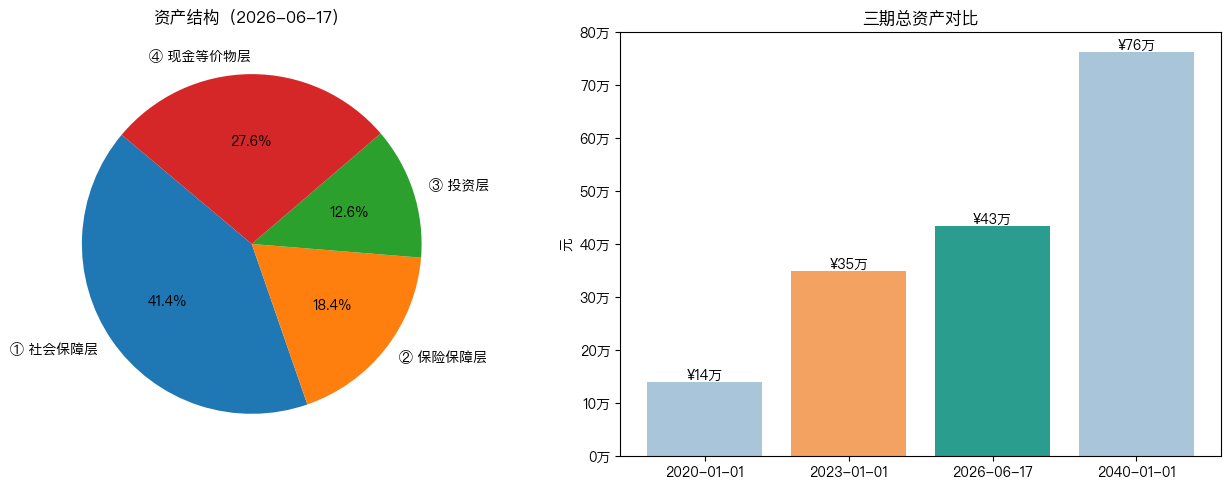

图表已保存：asset_overview.png


In [15]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as _fm
from matplotlib.ticker import FuncFormatter as _FF

# ── 中文字体 ──────────────────────────────────────────────
_cn_fonts = ['PingFang SC', 'PingFang HK', 'Heiti TC', 'STHeiti', 'SimHei', 'Microsoft YaHei']
_avail = {f.name for f in _fm.fontManager.ttflist}
_font  = next((f for f in _cn_fonts if f in _avail), None)
if _font:
    matplotlib.rcParams['font.family'] = _font
else:
    print('⚠ 未找到中文字体，图表标签可能显示方块')

matplotlib.rcParams.update({
    "figure.facecolor": "#F7F8FA",
    "axes.facecolor":   "#F7F8FA",
    "axes.titleweight": "bold",
    "axes.titlesize":   13,
    "font.size":        10,
    "axes.unicode_minus": False,
})

# ── 数据准备 ──────────────────────────────────────────────
_layer_names = list(df['layer'].unique())
_layer_vals  = [layer_totals[k]['mv'] for k in _layer_names]
_total_mv    = sum(_layer_vals)

_dates_str = [s['label'] for s in snaps]
_bar_vals  = [s['total'] for s in snaps]

# ── 绘图 ──────────────────────────────────────────────────
PIE_COLORS = ["#264653", "#2A9D8F", "#E9C46A", "#E76F51", "#8AB17D", "#7B8FA1"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5),
                          gridspec_kw={"width_ratios": [1, 1.25]},
                          facecolor="#F7F8FA")
fig.suptitle("个人资产概览", fontsize=18, fontweight="bold", color="#172B4D", y=1.02)

# 左图：环形图
wedges, _, autotexts = axes[0].pie(
    _layer_vals,
    startangle=90,
    counterclock=False,
    colors=PIE_COLORS[:len(_layer_vals)],
    autopct=lambda pct: f"{pct:.1f}%" if pct >= 3 else "",
    pctdistance=0.78,
    wedgeprops={"width": 0.38, "edgecolor": "#F7F8FA", "linewidth": 3},
)
for at in autotexts:
    at.set_color("white"); at.set_fontsize(9); at.set_fontweight("bold")

axes[0].text(0,  0.08, "总资产",             ha="center", color="#6B778C", fontsize=10)
axes[0].text(0, -0.09, f"¥{_total_mv:,.0f}", ha="center", color="#172B4D", fontsize=14, fontweight="bold")
axes[0].set_title(f"资产配置 · {TODAY}", pad=14, color="#172B4D")
axes[0].legend(
    wedges,
    [f"{n}  ¥{v:,.0f}" for n, v in zip(_layer_names, _layer_vals)],
    loc="lower center", bbox_to_anchor=(0.5, -0.22),
    ncol=2, frameon=False, fontsize=9,
)

# 右图：四期柱状图（末柱高亮）
_bar_colors = ["#B8C8D8"] * len(_bar_vals)
_bar_colors[-1] = "#2A9D8F"
bars = axes[1].bar(_dates_str, _bar_vals, width=0.56, color=_bar_colors, edgecolor="none")
_max_val = max(_bar_vals)
axes[1].set_ylim(0, _max_val * 1.18)

for i, (bar, val) in enumerate(zip(bars, _bar_vals)):
    cx = bar.get_x() + bar.get_width() / 2
    axes[1].text(cx, val + _max_val * 0.025,
                 f"¥{val:,.0f}", ha="center", va="bottom",
                 fontsize=9, fontweight="bold", color="#172B4D")
    if i > 0 and _bar_vals[i - 1]:
        pct = (val - _bar_vals[i - 1]) / _bar_vals[i - 1] * 100
        axes[1].text(cx, val * 0.92,
                     f"{'+' if pct >= 0 else ''}{pct:.1f}%",
                     ha="center", va="top", fontsize=8, fontweight="bold",
                     color="white" if i == len(_bar_vals) - 1 else "#44546A")

axes[1].set_title("总资产变化趋势", pad=14, color="#172B4D")
axes[1].set_ylabel("资产金额", fontsize=9)
axes[1].yaxis.set_major_formatter(_FF(lambda x, _: f"¥{x/1e4:,.0f}万"))
axes[1].grid(axis="y", color="#DDE2E8", linewidth=0.8, alpha=0.8)
axes[1].set_axisbelow(True)
axes[1].tick_params(axis="both", length=0, colors="#5E6C84", labelsize=8.5)

for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.tight_layout()
plt.savefig('asset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('图表已保存：asset_overview.png')